# Mounting drive to have access to the dataset

In [2]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent data
DATA_DIR = Path(
    "/content/drive/MyDrive/Github/why_do_I_keep_losing/data"
)

print(DATA_DIR)

Mounted at /content/drive
/content/drive/MyDrive/Github/why_do_I_keep_losing/data


/content/drive/MyDrive/Github/why_do_I_keep_losing/data/heroes/icons/anti_mage.png
Exists: True
Size: 10326
Size: (256, 144)
Mode: RGB


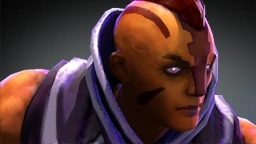

In [3]:
from pathlib import Path
from IPython.display import display
from PIL import Image

image_path = DATA_DIR / "heroes" / "icons" / "anti_mage.png"

image = Image.open(image_path)


print(image_path)
print("Exists:", image_path.exists())
print("Size:", image_path.stat().st_size if image_path.exists() else None)

print("Size:", image.size)
print("Mode:", image.mode)

display(image)

# Setting up environment and Github files

In [4]:
import os
import sys
import subprocess
from pathlib import Path
import importlib

REPO_URL = "https://github.com/Zekesy/why-do-I-keep-losing.git"
REPO_DIR = Path("/content/why_do_I_keep_losing")
SRC_DIR = REPO_DIR / "src"


if not REPO_DIR.exists():
    print("[INFO] Project not found. Cloning from GitHub...")
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True,
    )
else:
    print("[INFO] Project already exists.")
    subprocess.run(
        ["git", "-C", str(REPO_DIR), "checkout", "main"],
        check=False,
    )

    print("[INFO] Pulling latest changes...")
    subprocess.run(
        ["git", "-C", str(REPO_DIR), "pull", "origin", "main"],
        check=True,
    )

# Add src/ to Python path
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print()
print("Python source directory:")
print(SRC_DIR)

print()
print("src exists:", SRC_DIR.exists())
print(
    "package exists:",
    (SRC_DIR / "why_do_I_keep_losing").exists()
)

# Clear previously imported version of the package
for module_name in list(sys.modules):

    if (
        module_name == "why_do_I_keep_losing"
        or module_name.startswith("why_do_I_keep_losing.")
    ):
        del sys.modules[module_name]


# Import project
import why_do_I_keep_losing

print()
print("Package imported from:")
print(why_do_I_keep_losing.__file__)

# Verify important modules
from why_do_I_keep_losing.utils.data_setup import create_dataloaders

print()
print("✓ data_setup imported successfully")
print("✓ create_dataloaders is available")


# Move into project
os.chdir(REPO_DIR)
print()
print("=" * 50)
print("Project ready")
print("=" * 50)
print(f"Location: {REPO_DIR}")

[INFO] Project not found. Cloning from GitHub...

Python source directory:
/content/why_do_I_keep_losing/src

src exists: True
package exists: True

Package imported from:
/content/why_do_I_keep_losing/src/why_do_I_keep_losing/__init__.py

✓ data_setup imported successfully
✓ create_dataloaders is available

Project ready
Location: /content/why_do_I_keep_losing


# Testing imports are correct and Github is correctly set

[INFO] Found 3 parquet files
[INFO] Loaded 5939 unique matches
[WARNING] Icon not found for Anti-Mage: antimage.png
[INFO] Loaded 126 / 127 hero icons
DATASET
Total samples: 5939
Train samples: 4159
Val samples:   890
Test samples:  890

DATALOADERS
Train batches: 260
Val batches:   56
Test batches:  56

FIRST BATCH
Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Images dtype: torch.float32
Labels dtype: torch.float32
Device:       cpu

Labels:
tensor([1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0.])


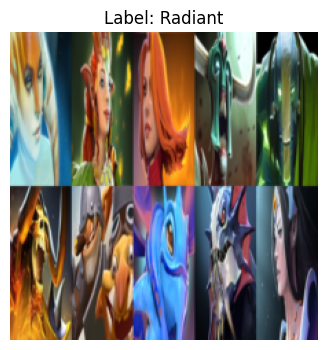

In [5]:
from torchvision import transforms
from why_do_I_keep_losing.utils.data_setup import create_dataloaders

PARQUET_PATH = DATA_DIR / "processed"
ICONS_DIR = DATA_DIR / "heroes" / "icons"

# Simple transform for testing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_loader, val_loader, test_loader, \
train_dataset, val_dataset, test_dataset = create_dataloaders(
    parquet_dir=str(PARQUET_PATH),
    icons_dir=str(ICONS_DIR),
    transform=transform,
    batch_size=16,
    val_split=0.15,
    test_split=0.15,
    num_workers=2,
)

print("============================================================")
print("DATASET")
print("============================================================")
print(f"Total samples: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

print("\n============================================================")
print("DATALOADERS")
print("============================================================")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Get one batch
images, labels = next(iter(train_loader))

print("\n============================================================")
print("FIRST BATCH")
print("============================================================")
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Images dtype: {images.dtype}")
print(f"Labels dtype: {labels.dtype}")
print(f"Device:       {images.device}")

print("\nLabels:")
print(labels)

import matplotlib.pyplot as plt

image = images[0]

plt.figure(figsize=(8, 4))
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {'Radiant' if labels[0].item() == 1 else 'Dire'}")
plt.axis("off")
plt.show()

# Training the Model

In [6]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from why_do_I_keep_losing.utils.data_setup import create_dataloaders
from why_do_I_keep_losing.engine.train import train
from why_do_I_keep_losing.models.hero_pic_ViT import HeroPicViT

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform



PARQUET_PATH = DATA_DIR / "processed"
ICONS_DIR = DATA_DIR / "heroes" / "icons"

model = HeroPicViT(
    model_name="vit_base_patch16_224",
    pretrained=True,
    drop_rate=0.2,
)

config = resolve_data_config({}, model=model.backbone)
vit_transforms = create_transform(**config)

torch.manual_seed(42)

train_loader, val_loader, test_loader, \
train_dataset, val_dataset, test_dataset = create_dataloaders(
    parquet_dir=str(PARQUET_PATH),
    icons_dir=str(ICONS_DIR),
    transform=vit_transforms,
    batch_size=16,
    val_split=0.15,
    test_split=0.15,
    num_workers=2,
)


loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

EPOCHS = 3
device = "cuda" if torch.cuda.is_available() else "cpu"

results = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs= EPOCHS,
    device=device,
)

print("\nFinal results:")
print(f"Train loss: {results['train_loss'][-1]:.4f}")
print(f"Train acc:  {results['train_acc'][-1]:.4f}")
print(f"Val loss:   {results['test_loss'][-1]:.4f}")
print(f"Val acc:    {results['test_acc'][-1]:.4f}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

[INFO] Found 3 parquet files
[INFO] Loaded 5939 unique matches
[WARNING] Icon not found for Anti-Mage: antimage.png
[INFO] Loaded 126 / 127 hero icons


Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Training:   0%|          | 0/260 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch: 02 | train_loss: 0.7152 | train_acc: 0.5003 | test_loss: 0.6982 | test_acc: 0.4710


Training:   0%|          | 0/260 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch: 03 | train_loss: 0.7196 | train_acc: 0.5136 | test_loss: 0.6938 | test_acc: 0.4710

Final results:
Train loss: 0.7196
Train acc:  0.5136
Val loss:   0.6938
Val acc:    0.4710


# Visualize the results

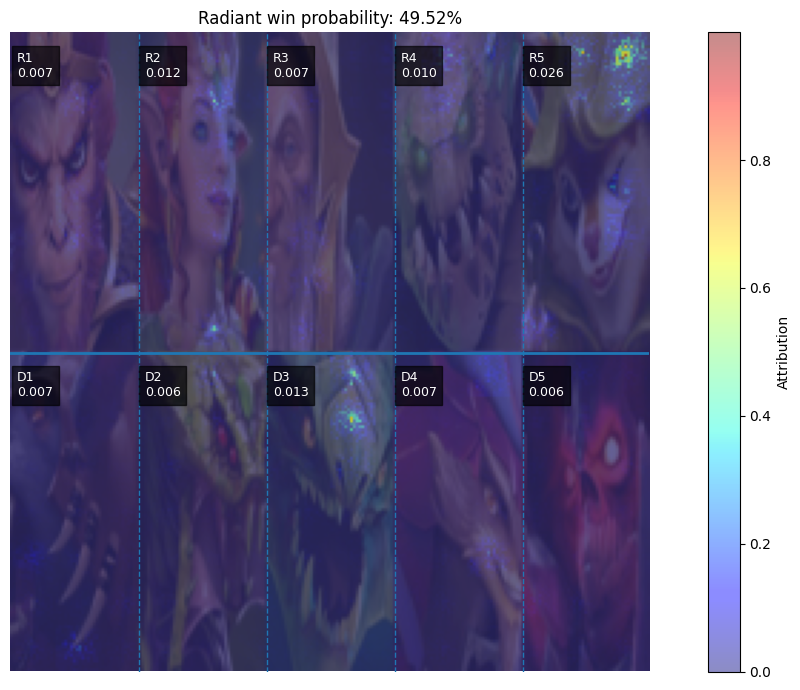

In [7]:
from why_do_I_keep_losing.utils.visualization import get_hero_attributions, visualize_hero_attributions

image, label = test_dataset[0]

attribution, hero_scores, logit = get_hero_attributions(
    model=model,
    image=image,
    device=device,
)

visualize_hero_attributions(
    image=image,
    attribution=attribution,
    hero_scores=hero_scores,
    logit=logit,
)